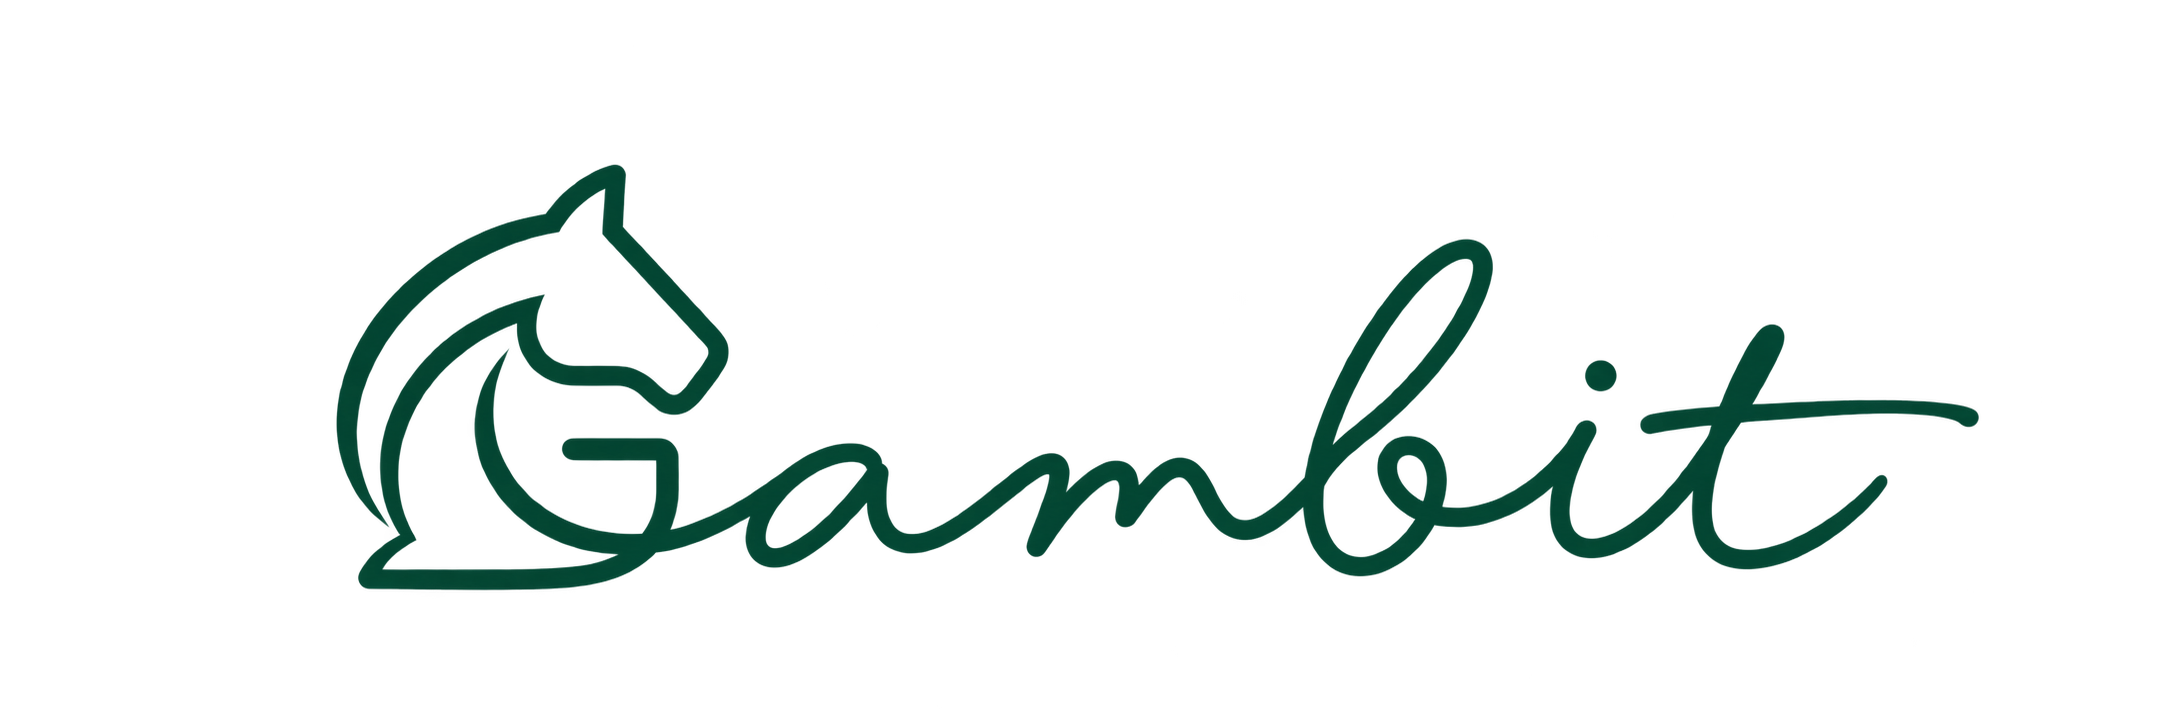

### **Multi-Agent Competitive Intelligence System**

**Input:**

To options

1.   Existing Company
2.   Startup Idea


**Output:**

| For an existing company | For a startup idea |
|---|---|
| Overall assessment | Verdict: **BUILD, VALIDATE FIRST, or RECONSIDER** |
| Biggest competitive threat | Customer problem |
| Biggest customer insight | Customer need |
| Biggest opportunity | named competitors or alternatives |
| Biggest competitive gap | Market gap |
| Recommended action | Recommended next step |
| Confidence level and sources | Confidence level and sources |



In [1]:
!pip install -qU \
    langgraph \
    langchain \
    langchain-google-genai \
    google-genai \
    tavily-python \
    pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.0/256.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.4/162.4 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.61.0 which is incompatible.


##**Imports**

In [2]:
import os
import json
import re
from google.colab import userdata

from typing import TypedDict, Annotated, List, Dict, Any, Optional

from pydantic import BaseModel, Field

from langchain.tools import tool
from langchain.agents import create_agent

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
)

from langchain_core.tools import tool

from tavily import TavilyClient

## **API Keys**


In [3]:
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")

print("API keys loaded successfully.")

API keys loaded successfully.


##**Model Architecture**

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

MODEL_NAME = "gemini-3.5-flash-lite"

model = ChatGoogleGenerativeAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=3,
)


##**Agents class**



In [5]:
class GambitState(TypedDict, total=False):

    # User request
    request: str

    # 1- Intent / context
    mode: str                  # "company" or "startup"
    subject: str               # company name or product/startup idea
    industry: str
    market: str
    target_customer: str

    # 2- Research
    competitors: list
    competitor_research: str
    product_analysis: str
    customer_analysis: str
    market_analysis: str

    # 3- Strategy
    strategy_analysis: str

    # 4- Critic
    critique: dict
    critique_decision: str

    # 5- Revision control
    revision_count: int
    max_revisions: int

    # 6- Final output
    final_snapshot: str

## **Web Search tool**

In [6]:
from langchain_core.tools import tool

tavily_client = TavilyClient(
    api_key=os.environ["TAVILY_API_KEY"]
)

@tool
def google_search(query: str) -> str:
    """Search the live web using Tavily and return snippets and sources."""

    response = tavily_client.search(
        query=query,
        search_depth="basic",
        max_results=5,
        include_answer=False,
    )

    results = [
        {
            "title": item.get("title", ""),
            "url": item.get("url", ""),
            "content": item.get("content", ""),
        }
        for item in response.get("results", [])
    ]

    return json.dumps(
        {"results": results},
        ensure_ascii=False,
        indent=2,
    )


## **Linkedin Search tool**

In [7]:
@tool
def linkedin_search(query: str) -> str:
    """
    Search publicly indexed LinkedIn pages.
    Useful for company pages, organizations,
    founders, executives, and professional signals.
    """

    response = tavily_client.search(
        query=f"site:linkedin.com {query}",
        search_depth="basic",
        topic="general",
        max_results=5,
        include_domains=["linkedin.com"],
        include_answer=False
    )

    results = []

    for item in response.get("results", []):
        results.append({
            "title": item.get("title", ""),
            "url": item.get("url", ""),
            "content": item.get("content", "")
        })

    return json.dumps(
        results,
        ensure_ascii=False,
        indent=2
    )

## **Intent Agent Creation**

In [8]:
intent_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="""
You are GAMBIT's Intent Agent.

Determine whether the user's request is about:

1. An EXISTING COMPANY
2. A NEW PRODUCT / STARTUP IDEA

Extract:

- mode
- subject
- industry
- market
- target_customer

Rules:

For an existing company:
mode = "company"

For a new product, business idea, or startup:
mode = "startup"

Return ONLY JSON:

{
  "mode": "company" or "startup",
  "subject": "...",
  "industry": "...",
  "market": "...",
  "target_customer": "..."
}

Do not invent missing details.
Use "Unknown" when information is unavailable.
"""
)

## **Competitor Agent Creation**



In [9]:
competitor_agent = create_agent(
    model=model,
    tools=[
        google_search,
        linkedin_search
    ],
    system_prompt="""
You are GAMBIT's Competitor Intelligence Agent.

Your job is to identify the most important competitive
alternatives for the user's request.

For COMPANY mode:
- Identify major direct competitors.

For STARTUP mode:
- Identify direct competitors.
- Identify important indirect competitors.
- Identify alternative solutions customers could use instead.

Use Google Search for current evidence.
Use LinkedIn when useful for company verification.

Find only 2-4 highly relevant competitors.

For each competitor explain:
- Name
- Why it is relevant
- Evidence

Do not invent competitors.
Keep the result concise.
"""
)

## **Product Agent Creation**

In [10]:
product_agent = create_agent(
    model=model,
    tools=[
        google_search
    ],
    system_prompt="""
You are GAMBIT's Product Intelligence Agent.

For COMPANY mode:
Analyze the target company's product/service position
relative to major competitors.

For STARTUP mode:
Analyze how the proposed product could differentiate
from existing solutions.

Focus ONLY on:
- Main offering
- Key differentiator
- Pricing/positioning when available
- Important product gap

Do not produce a long report.
Return concise evidence-based findings.
Include important sources.
"""
)

## **Customer Agent Creation**

---




In [11]:
customer_agent = create_agent(
    model=model,
    tools=[
        google_search
    ],
    system_prompt="""
You are GAMBIT's Customer Intelligence Agent.

For COMPANY mode:
Find the most important customer insight affecting
competitive position.

For STARTUP mode:
Determine whether there is evidence of a real customer
problem or unmet need.

Focus on:
- Customer pain points
- Customer priorities
- Positive or negative signals
- Unmet needs

Do not confuse assumptions with evidence.

Return only the most important findings.
"""
)

## **Market Agent Creation**


In [12]:
market_agent = create_agent(
    model=model,
    tools=[
        google_search
    ],
    system_prompt="""
You are GAMBIT's Market Intelligence Agent.

Analyze the relevant market using current web information.

Focus on:
- One or two major trends
- Opportunity or threat
- Why it matters now

For STARTUP mode:
Focus especially on whether the market appears attractive.

For COMPANY mode:
Focus especially on changes that could affect competitiveness.

Keep the analysis concise.
"""
)

## **Strategy Agent Creation**

In [13]:
strategy_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="""
You are GAMBIT's Strategy Agent.

You receive research from specialized agents.

For COMPANY mode, determine:
- Biggest competitive threat
- Biggest customer insight
- Biggest opportunity
- Biggest competitive gap
- Best next action

For STARTUP mode, determine:
- Strength of the problem
- Competitive pressure
- Market opportunity
- Biggest market gap
- Whether the idea should be built, validated first,
  or reconsidered
- Best next validation step

Use the provided evidence.
Do not invent facts.

If critic feedback is provided,
revise your previous recommendation.

Keep the strategic conclusion concise.
"""
)

## **Critic Agent Creation**


In [14]:
critic_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="""
You are GAMBIT's Critic Agent.

Review the strategic analysis.

Check:

- Is the conclusion supported by evidence?
- Are important competitors missing?
- Is customer demand being assumed?
- Are recommendations too confident?
- Are there contradictions?
- Is any major evidence missing?

Return ONLY JSON:

{
  "decision": "PASS" or "REVISE",
  "reasoning": "...",
  "issues": [
    "..."
  ],
  "recommended_changes": [
    "..."
  ]
}

Use REVISE when the analysis needs meaningful improvement.
Use PASS when it is sufficiently supported.
"""
)

## **Executive Agent Creation**

In [15]:
executive_agent = create_agent(
    model=model,
    tools=[],
    system_prompt="""
You are GAMBIT's Executive Agent.

Create a SHORT, SIMPLE, and ACTIONABLE strategic snapshot.

The user should understand the result on the first read.
Clarity is more important than sounding professional or sophisticated.


LANGUAGE RULES:

Write for a normal business owner, not a consultant or researcher.

- Use simple, clear English.
- Prefer everyday words over business jargon.
- Keep sentences short.
- Explain the idea directly.
- Avoid corporate or academic language.
- If a business term is necessary, explain it simply.
- Adapt your language to the type of business being analyzed.
- Do not make a simple business idea sound like a technology startup.


SPECIFICITY RULES:

- Be specific instead of vague.
- Use real company and competitor names when supported by research.
- Do not say "major competitors" without naming them.
- Do not say "existing platforms" when their names are known.
- When useful, explain what makes each competitor different.
- Never invent a business, statistic, customer need, or market fact.
- For the competition section, name 2-4 competitors when reliable
  competitors were found.
- If there are no clear direct competitors, say so and mention the
  closest alternatives.


For COMPANY mode, output exactly:

Strategic Snapshot

Overall Assessment:
[one simple sentence]

1. Biggest Competitive Threat
[Name the competitor when possible and explain the threat simply]

2. Biggest Customer Insight
[one concise finding]

3. Biggest Opportunity
[one concise finding]

4. Biggest Competitive Gap
[one concise finding]

5. Recommended Action
[one clear and practical action]

Confidence:
[Low / Medium / High]

Key Sources:
[3-5 most important URLs]


For STARTUP mode, output exactly:

Startup Validation Snapshot

Opportunity Verdict:
[BUILD / VALIDATE FIRST / RECONSIDER]

1. Problem
[Explain the problem simply]

2. Customer Need
[Explain what customers actually need]

3. Main Competitors
[Name 2-4 real competitors or alternatives and briefly explain why each matters]

Rules for competitors:
- Always mention competitor names when reliable competitors were found.
- Include only competitors supported by the research.
- Do not invent competitor names.
- Prefer competitors operating in or relevant to the user's target market.
- Explain each competitor in simple language.
- If there are no clear direct competitors, say so and name the closest alternatives.

4. Market Gap
[Explain what is missing from the current market]

5. Recommended Next Step
[Give one specific and practical action]

Opportunity Confidence:
[Low / Medium / High]

Key Sources:
[3-5 most important URLs]


Do not add extra sections.
Do not invent information.
"""
)

## **Response helpers**

In [16]:
def get_message_text(message):
    """
    Convert a LangChain message content into plain text.
    Works whether Gemini returns a string or content blocks.
    """

    content = message.content

    # Normal string response
    if isinstance(content, str):
        return content

    # Gemini may return a list of content blocks
    if isinstance(content, list):
        parts = []

        for block in content:
            if isinstance(block, str):
                parts.append(block)

            elif isinstance(block, dict):
                if "text" in block:
                    parts.append(block["text"])

        return "".join(parts)

    return str(content)


def parse_json_response(message):
    """
    Extract JSON safely from an LLM response.
    """

    text = get_message_text(message).strip()

    # Remove markdown fences if Gemini adds them
    if text.startswith("```json"):
        text = text[7:]
    elif text.startswith("```"):
        text = text[3:]

    if text.endswith("```"):
        text = text[:-3]

    return json.loads(text.strip())

## **Intent Node Creation**


In [17]:
def intent_node(state: GambitState):

    result = intent_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": state["request"]
            }
        ]
    })

    parsed = parse_json_response(
        result["messages"][-1]
    )

    return {
        "mode": parsed.get("mode", "startup"),
        "subject": parsed.get("subject", "Unknown"),
        "industry": parsed.get("industry", "Unknown"),
        "market": parsed.get("market", "Unknown"),
        "target_customer": parsed.get(
            "target_customer",
            "Unknown"
        )
    }

## **Competitor Node Creation**


In [18]:
def competitor_node(state: GambitState):

    prompt = f"""
    Analyze this request:

    Mode: {state["mode"]}
    Subject: {state["subject"]}
    Industry: {state["industry"]}
    Market: {state["market"]}
    Target Customer: {state["target_customer"]}

    Identify the 2-4 most important competitors or alternatives.
    """

    result = competitor_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
        "competitor_research":
            get_message_text(result["messages"][-1])

    }

## **Product Node Creation**

In [19]:
def product_node(state: GambitState):

    prompt = f"""
    Analyze the product situation.

    Mode: {state["mode"]}
    Subject: {state["subject"]}
    Industry: {state["industry"]}
    Market: {state["market"]}

    Competitor research:
    {state.get("competitor_research", "")}
    """

    result = product_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
    "product_analysis":
        get_message_text(result["messages"][-1])
}

## **Customer Node Creation**


In [20]:
def customer_node(state: GambitState):

    prompt = f"""
    Analyze the customer perspective.

    Mode: {state["mode"]}
    Subject: {state["subject"]}
    Industry: {state["industry"]}
    Market: {state["market"]}
    Target Customer: {state["target_customer"]}

    Competitor research:
    {state.get("competitor_research", "")}
    """

    result = customer_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
        "customer_analysis":
           get_message_text(result["messages"][-1])

    }

## **Market Node Creation**


In [21]:
def market_node(state: GambitState):

    prompt = f"""
    Analyze the current market.

    Mode: {state["mode"]}
    Subject: {state["subject"]}
    Industry: {state["industry"]}
    Market: {state["market"]}

    Competitor research:
    {state.get("competitor_research", "")}
    """

    result = market_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
        "market_analysis":
        get_message_text(result["messages"][-1])

    }

## **strategy Node Creation**


In [22]:
def strategy_node(state: GambitState):

    prompt = f"""
    Create the strategic conclusion.

    Mode:
    {state["mode"]}

    Subject:
    {state["subject"]}

    Industry:
    {state["industry"]}

    Market:
    {state["market"]}

    Competitor Research:
    {state.get("competitor_research", "")}

    Product Analysis:
    {state.get("product_analysis", "")}

    Customer Analysis:
    {state.get("customer_analysis", "")}

    Market Analysis:
    {state.get("market_analysis", "")}

    Previous Critic Feedback:
    {json.dumps(state.get("critique", {}), ensure_ascii=False)}

    Revision:
    {state.get("revision_count", 0)}

    Produce the strategic conclusion according to your role.
    """

    result = strategy_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
        "strategy_analysis":
            get_message_text(result["messages"][-1])

    }

## **Critique Node Creation**


In [23]:
def critique_node(state: GambitState):

    prompt = f"""
    Review the following strategic conclusion.

    Mode:
    {state["mode"]}

    Subject:
    {state["subject"]}

    Research:
    Competitors:
    {state.get("competitor_research", "")}

    Product:
    {state.get("product_analysis", "")}

    Customer:
    {state.get("customer_analysis", "")}

    Market:
    {state.get("market_analysis", "")}

    Strategy:
    {state.get("strategy_analysis", "")}
    """

    result = critic_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    critique = parse_json_response(
    result["messages"][-1]
    )
    decision = critique.get("decision", "REVISE").upper()

    revision_count = state.get("revision_count", 0)
    max_revisions = state.get("max_revisions", 2)

    if decision == "REVISE" and revision_count >= max_revisions:
        decision = "PASS"

    if decision == "REVISE":
        revision_count += 1

    return {
        "critique": critique,
        "critique_decision": decision,
        "revision_count": revision_count
    }

## **Router Creation**


In [24]:
def route_after_critique(state: GambitState):

    if state["critique_decision"] == "REVISE":
        return "strategy"

    return "executive"

## **Executive Node Creation**


In [25]:
def executive_node(state: GambitState):

    prompt = f"""
    Create the final GAMBIT snapshot.

    Mode:
    {state["mode"]}

    Subject:
    {state["subject"]}

    Industry:
    {state["industry"]}

    Market:
    {state["market"]}

    Competitor Research:
    {state.get("competitor_research", "")}

    Product Analysis:
    {state.get("product_analysis", "")}

    Customer Analysis:
    {state.get("customer_analysis", "")}

    Market Analysis:
    {state.get("market_analysis", "")}

    Final Strategy:
    {state.get("strategy_analysis", "")}

    Critic:
    {json.dumps(state.get("critique", {}), ensure_ascii=False)}

    Follow your exact short output format.
    """

    result = executive_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    })

    return {
        "final_snapshot":
        get_message_text(result["messages"][-1])

    }

## **Graph Nodes Builder**


In [26]:
graph_builder = StateGraph(GambitState)

graph_builder.add_node("intent", intent_node)
graph_builder.add_node("competitor", competitor_node)

graph_builder.add_node("product", product_node)
graph_builder.add_node("customer", customer_node)
graph_builder.add_node("market", market_node)

graph_builder.add_node("strategy", strategy_node)
graph_builder.add_node("critique", critique_node)
graph_builder.add_node("executive", executive_node)

## **Graph Edges Builder**


In [27]:
graph_builder.add_edge(
    START,
    "intent"
)

graph_builder.add_edge(
    "intent",
    "competitor"
)

graph_builder.add_edge(
    "competitor",
    "product"
)

graph_builder.add_edge(
    "competitor",
    "customer"
)

graph_builder.add_edge(
    "competitor",
    "market"
)

graph_builder.add_edge(
    "product",
    "strategy"
)

graph_builder.add_edge(
    "customer",
    "strategy"
)

graph_builder.add_edge(
    "market",
    "strategy"
)

graph_builder.add_edge(
    "strategy",
    "critique"
)

graph_builder.add_conditional_edges(
    "critique",
    route_after_critique,
    {
        "strategy": "strategy",
        "executive": "executive"
    }
)

graph_builder.add_edge(
    "executive",
    END
)

## **Model Compilation**


In [28]:
gambit = graph_builder.compile()

##**Visualize Graph**

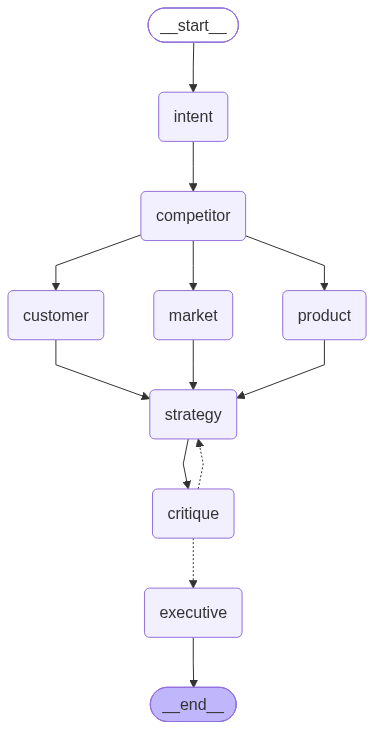

In [29]:
from IPython.display import Image, display

display(
    Image(
        gambit.get_graph().draw_mermaid_png()
    )
)

##**Run GAMBIT**

In [30]:
request = input(
    "Describe the company or startup/product idea you want GAMBIT to analyze:\n"
)

Describe the company or startup/product idea you want GAMBIT to analyze:
i want to create a flowers website 


In [31]:
initial_state = GambitState(
    request=request,
    revision_count=0,
    max_revisions=2
)

final_state = gambit.invoke(initial_state)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_

##**Display Final Report**

In [32]:

print(final_state["final_snapshot"])

Startup Validation Snapshot

Opportunity Verdict:
RECONSIDER

1. Problem
Traditional flower delivery networks are expensive and unreliable, often delivering wilted arrangements that look nothing like the website pictures.

2. Customer Need
Modern buyers want trendy, aesthetically pleasing flower arrangements and transparent, eco-friendly sourcing without paying hidden legacy fees.

3. Main Competitors
- The Bouqs Company: A popular direct-to-consumer brand known for eco-friendly, farm-direct sourcing and subscriptions.
- UrbanStems: A design-forward online florist focusing on trendy arrangements and lifestyle brand partnerships.
- FTD & 1-800-Flowers: Legacy networks that route orders to local flower shops but face complaints about high fees and variable quality.
- DoorDash & Instacart: Quick-delivery apps that let users buy flowers instantly, bypassing dedicated flower websites.

4. Market Gap
There is a gap between premium online brands that take days to ship boxed stems and instant 

##**Download Final Report**

In [33]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"GAMBIT_Snapshot_{timestamp}.md"

with open(filename, "w", encoding="utf-8") as f:
    f.write(final_state["final_snapshot"])
    f.write("\n")

print(f"Snapshot saved as: {filename}")

Snapshot saved as: GAMBIT_Snapshot_20261008_061526.md
